# 검수 확인서 테스트

In [32]:
import sys
import os
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_teddynote import logging
from langchain.agents.middleware import TodoListMiddleware
from langchain.agents import create_agent
from pathlib import Path
from IPython.display import Markdown, display

from dotenv import load_dotenv

load_dotenv(override=True)

# 추적을 위한 프로젝트 이름 설정
logging.langsmith("Samsung-Asset-AI-Portal")

# prompt 모듈에서 필요한 항목 import
from prompt import (
    _SYSTEM_PROMPT,
    _SYSTEM_PROMPT_ENG,
    get_prompt_pdf_text_to_markdown,
    get_prompt_text_to_markdown,
    get_prompt_pdf_text_to_markdown_validate,
    get_prompt_text_to_markdown_validate,
    get_prompt_confirmed_expected_clarification,
    get_prompt_text_to_markdown_validate_report,
    get_prompt_text_to_markdown_error_fix,
    get_prompt_confirmed_expected_clarification_validate_report,
    get_prompt_confirmed_expected_clarification_error_fix
)

# document_parser 모듈에서 필요한 함수들 import
from document_parser import (
    extract_pdf_with_docling,
    extract_pdf_with_pdfplumber,
    parser_excel,
    get_file_path,
    get_last_ai_message
)

from utils import (
    format_messages,
    extract_validate_result,
    has_validate_result,
    check_validate_result,
)

_original_text = None

LangSmith 추적을 시작합니다.
[프로젝트명]
Samsung-Asset-AI-Portal


# LLM 모델 생성

In [33]:
# LLM 모델 정의

LLM_MODEL = os.getenv("LLM_MODEL")
LLM_BASE_URL=os.getenv("LLM_BASE_URL")
LLM_API_KEY=os.getenv("LLM_API_KEY")

def create_llm_model():

    # vLLM 모델 인스턴스 생성
    llm = init_chat_model(
        "openai:",
        temperature=0.0,
        top_p=0.1,  # top_p는 (0, 1] 범위여야 하므로 0.1로 설정
        base_url=LLM_BASE_URL,
        api_key=LLM_API_KEY
    )
    # llm = init_chat_model(
    #     "openai:gpt-4o",
    #     temperature=0.0,
    #     top_p=0.1,  # top_p는 (0, 1] 범위여야 하므로 0.9로 설정
    # )
    return llm

# excel to markdown

In [34]:
# 싱글톤 
def text_to_markdown_with_llm(document_text: str):
    # 메시지 객체 생성
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_prompt = get_prompt_text_to_markdown(document_text)
    print("########## text to markdown prompt ##########")
    print(human_prompt)
    human_msg = HumanMessage(human_prompt)

    # 채팅 모델과 함께 사용
    messages = [system_msg, human_msg]

    llm = create_llm_model()
    response = llm.invoke(messages)  # AIMessage 반환

    return response


# todos 미들웨어 사용
def text_to_markdown_with_plan(document_text: str):
    llm = create_llm_model()
    human_prompt = get_prompt_text_to_markdown(document_text)
    print("########## text to markdown prompt ##########")
    print(human_prompt)
    todo_agent = create_agent(
        llm,
        system_prompt=_SYSTEM_PROMPT,
        middleware=[TodoListMiddleware()]
    )

    response = todo_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response

def convert_excel_to_markdown(file_path: str):
    # 엑셀 파일 경로 확인
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    # 엑셀 파일에서 텍스트 추출
    _original_text = parser_excel(file_path)

    # 텍스트를 markdown으로 변환
    response_markdown = text_to_markdown_with_plan(_original_text)
    # response_markdown = text_to_markdown_with_llm(_original_text)
    # markdown_text = get_last_ai_message(response_markdown)

    return response_markdown


# document to markdown

In [35]:
def document_to_markdown(file_path: str):
    path_obj = Path(file_path)
    file_name = path_obj.name  # 파일명 (확장자 포함)
    file_ext = path_obj.suffix  # 확장자 (점 포함, 예: .pdf)
    markdown_text = None

    if file_ext == ".xlsx" or file_ext == ".xls":
        markdown_text = convert_excel_to_markdown(file_path)
    elif file_ext == ".pdf":
        print("pdf - 공사중...")
    else:
        print("지원하지 않는 파일 형식입니다.")

    return markdown_text


# markdown 정리 문서 검수 보고서 작성

In [36]:
# 싱글톤 
def text_to_markdown_validate_report_with_llm(markdown_text: str, original_text: str):
    # 메시지 객체 생성
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_prompt = get_prompt_text_to_markdown_validate_report(markdown_text, original_text)
    print("########## 검수보고서 작성 prompt ##########")
    print(human_prompt)
    human_msg = HumanMessage(human_prompt)

    # 채팅 모델과 함께 사용
    messages = [system_msg, human_msg]

    llm = create_llm_model()
    response = llm.invoke(messages)  # AIMessage 반환

    return response


# todos 미들웨어 사용
def text_to_markdown_validate_report_with_plan(markdown_text: str, original_text: str):
    llm = create_llm_model()
    human_prompt = get_prompt_text_to_markdown_validate_report(markdown_text, original_text)
    print("########## 검수보고서 작성 prompt ##########")
    print(human_prompt)
    todo_agent = create_agent(
        llm,
        system_prompt=_SYSTEM_PROMPT,
        middleware=[TodoListMiddleware()]
    )

    response = todo_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response

# markdown 정리 문서 오류 수정

In [37]:
# 싱글톤 
def text_to_markdown_error_fix_with_llm(markdown_text: str, validate_report: str, original_text: str):
    # 메시지 객체 생성
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_prompt = get_prompt_text_to_markdown_error_fix(markdown_text, original_text, validate_report)
    print("########## 오류 수정 prompt ##########")
    print(human_prompt)
    human_msg = HumanMessage(human_prompt)

    # 채팅 모델과 함께 사용
    messages = [system_msg, human_msg]

    llm = create_llm_model()
    response = llm.invoke(messages)  # AIMessage 반환

    return response


# todos 미들웨어 사용
def text_to_markdown_error_fix_with_plan(markdown_text: str, validate_report: str, original_text: str):
    llm = create_llm_model()
    human_prompt = get_prompt_text_to_markdown_error_fix(markdown_text, original_text, validate_report)
    print("########## 오류 수정 prompt ##########")
    print(human_prompt)
    todo_agent = create_agent(
        llm,
        system_prompt=_SYSTEM_PROMPT,
        middleware=[TodoListMiddleware()]
    )

    response = todo_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response

# 확정분/청구분 정리

In [38]:
# markdown으로 정리된 지시서를 받아 확정분과 청구분으로 구분하여 데이터 정리
# 싱글톤
def classify_confirmed_expected_from_instruction_with_llm(instruction_markdown: str):

    # 메시지 객체 생성
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_prompt = get_prompt_confirmed_expected_clarification(instruction_markdown)
    human_msg = HumanMessage(human_prompt)
    print("########## 확정분/청구분 구분 prompt ##########")
    print(human_prompt)
    # 채팅 모델과 함께 사용
    messages = [system_msg, human_msg]

    llm = create_llm_model()
    response = llm.invoke(messages)  # AIMessage 반환

    return response


# todos 미들웨어 사용
def classify_confirmed_expected_from_instruction_with_plan(instruction_markdown: str):
    llm = create_llm_model()
    human_prompt = get_prompt_confirmed_expected_clarification(instruction_markdown)
    print("########## 확정분/청구분 구분 prompt ##########")
    print(human_prompt)
    todo_agent = create_agent(
        llm,
        system_prompt=_SYSTEM_PROMPT,
        middleware=[TodoListMiddleware()]
    )

    response = todo_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response

# 확정분/청구분 분류 결과 검수

In [39]:
# 싱글톤
def classify_confirmed_expected_validate_report_with_llm(clarification_markdown: str, instruction_markdown: str):

    # 메시지 객체 생성
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_prompt = get_prompt_confirmed_expected_clarification_validate_report(clarification_markdown, instruction_markdown)
    human_msg = HumanMessage(human_prompt)
    print("########## 확정분/청구분 검수 prompt ##########")
    print(human_prompt)
    # 채팅 모델과 함께 사용
    messages = [system_msg, human_msg]

    llm = create_llm_model()
    response = llm.invoke(messages)  # AIMessage 반환

    return response


# todos 미들웨어 사용
def classify_confirmed_expected_validate_report_with_plan(clarification_markdown: str, instruction_markdown: str):
    llm = create_llm_model()
    human_prompt = get_prompt_confirmed_expected_clarification_validate_report(clarification_markdown, instruction_markdown)
    print("########## 확정분/청구분 검수 prompt ##########")
    print(human_prompt)
    todo_agent = create_agent(
        llm,
        system_prompt=_SYSTEM_PROMPT,
        middleware=[TodoListMiddleware()]
    )

    response = todo_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response

# 확정분/청구분 오류 수정

In [40]:
# 싱글톤
def classify_confirmed_expected_error_fix_with_llm(validate_report: str, clarification_markdown: str, instruction_markdown: str):

    # 메시지 객체 생성
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_prompt = get_prompt_confirmed_expected_clarification_error_fix(validate_report, clarification_markdown, instruction_markdown)
    human_msg = HumanMessage(human_prompt)
    print("########## 확정분/청구분 오류 수정 prompt ##########")
    print(human_prompt)
    # 채팅 모델과 함께 사용
    messages = [system_msg, human_msg]

    llm = create_llm_model()
    response = llm.invoke(messages)  # AIMessage 반환

    return response


# todos 미들웨어 사용
def classify_confirmed_expected_error_fix_with_plan(validate_report: str, clarification_markdown: str, instruction_markdown: str):
    llm = create_llm_model()
    human_prompt = get_prompt_confirmed_expected_clarification_error_fix(validate_report, clarification_markdown, instruction_markdown)
    print("########## 확정분/청구분 오류 수정 prompt ##########")
    print(human_prompt)
    todo_agent = create_agent(
        llm,
        system_prompt=_SYSTEM_PROMPT,
        middleware=[TodoListMiddleware()]
    )

    response = todo_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response

# Graph State

In [41]:
# Graph state 클래스

from typing_extensions import TypedDict

class State(TypedDict):
    file_path: str # 변액일임펀드 설정/해지 지시서 파일 경로
    file_name: str # 지시서 파일 이름
    file_ext: str # 지시서 파일 확장자
    password: str # 지시서 암호
    original_text_docling: str # 지시서 원본 텍스트 - docling
    original_text_pdfplumber: str # 지시서 원본 텍스트 - pdfplumber
    original_text: str # 지시서 원본 텍스트
    markdown_text: str # 지시서 마크다운 텍스트
    relevance_score: str # 지시서 여부 점수 : yes, no
    report_validate_markdown: str # 지시서 검수 보고서
    confirmed_expected_data: str # 지시서 확정분과 청구분 구분 결과
    report_validate_confirmed_expected: str # 지시서 확정분과 청구분 검수 보고서
    expected_data: str # 지시서 청구분 데이터
    confirmed_data: str # 지시서 확정분 데이터
    expected_subscription_data: str # 지시서 청구분 설정 데이터
    expected_redemption_data: str # 지시서 청구분 해지 데이터
    confirmed_subscription_data: str # 지시서 확정분 설정 데이터
    confirmed_redemption_data: str # 지시서 확정분 해지 데이터

# Node - 문서 정보 수집

In [42]:
from pathlib import Path

def node_get_document_info(state: State) -> State:
    file_path = state["file_path"]
    
    # file_path에서 파일명과 확장자 추출    
    path_obj = Path(file_path)
    file_name = path_obj.name  # 파일명 (확장자 포함)
    file_ext = path_obj.suffix  # 확장자 (점 포함, 예: .pdf)

    print(f"   file_path : {file_path}")
    print(f"   file_name : {file_name}")
    print(f"   file_ext : {file_ext}")
    
    return {"file_name": file_name, "file_ext": file_ext}


# Node - PDF 문서 파싱 - docling

In [43]:
# 노드 - PDF 문서 파싱 - docling
def node_parse_pdf_document_docling(state: State) -> State:
    file_path = state["file_path"]
    password = state["password"]
    pdf_text = extract_pdf_with_docling(file_path, password)

    print("docling")
    # print(pdf_text)

    return {"original_text_docling": pdf_text}


# Node - PDF 문서 파싱 - pdfplumber

In [44]:
# 노드 - PDF 문서 파싱 - pdfplumber
def node_parse_pdf_document_pdfplumber(state: State) -> State:
    file_path = state["file_path"]
    password = state["password"]
    pdf_text = extract_pdf_with_pdfplumber(file_path, password)

    print("pdfplumber")
    # print(pdf_text)

    return {"original_text_pdfplumber": pdf_text}

# Node - PDF 추출 텍스트 병합

In [45]:
# 지시서 여부를 확인하기 위해...
def node_merge_pdf_text(state: State) -> State:
    pdfplumber_text = state["original_text_pdfplumber"]
    docling_text = state["original_text_docling"]
    if docling_text == "":
        state["original_text_docling"] = pdfplumber_text
        print("docling_text is empty")

    print("merge")
    # print(pdfplumber_text)

    return {"original_text": pdfplumber_text}

# Node - excel 문서 파서

In [46]:
def node_parse_excel_document(state: State) -> State:
    file_path = state["file_path"]
    original_text = parser_excel(file_path)

    # print("****************excel parser****************")
    # print(f"   {original_text}")
    
    return {"original_text": original_text}


# Node - 문서 관련성 체크

In [47]:
# 노드 - 문서 관련성 체크 노드
def node_check_relevance(state: State) -> State:
    original_text = state["original_text"]
    # chain_retrieval_grader = create_chain_retrieval_grader()
    # relevance_score = chain_retrieval_grader.invoke({"original_text": original_text})
    relevance_score = "yes"
    # print("****************check_relevance****************")
    # print(f"   {relevance_score}")
    return {"relevance_score": relevance_score}
    # return {"relevance_score": relevance_score.binary_score}


# Node - markdown 변환

In [48]:
def node_convert_text_to_markdown(state: State) -> State:
    print("****************START node_convert_text_to_markdown****************")
    file_ext = state["file_ext"]
    markdown_text = None

    if file_ext == ".pdf":
        document_text_docling = state["original_text_docling"]
        document_text_pdfplumber = state["original_text_pdfplumber"]
        # response = convert_pdf_text_to_markdown_using_agent(document_text_docling, document_text_pdfplumber)
        # response = convert_pdf_text_to_markdown(document_text_docling, document_text_pdfplumber)        
        print("****************pdf markdown****************")
        # markdown_text = response.content
        # print(f"   {markdown_text}")
    elif file_ext == ".xlsx" or state["file_ext"] == ".xls":
        original_text = state["original_text"]  
        response = text_to_markdown_with_plan(original_text)
        # response = text_to_markdown_with_llm(original_text)
        print("****************excel markdown****************")
    else:
        original_text = state["original_text"]
        response = text_to_markdown_with_plan(original_text)
        # response = text_to_markdown_with_llm(original_text)        
        print("****************unknown markdown****************")

    markdown_text = get_last_ai_message(response)
    markdown_text = markdown_text.content

    print(markdown_text)

    return {
        "markdown_text": markdown_text
    }


# Node - 변환된 markdown 검수

In [49]:
def node_validate_report_markdown(state: State) -> State:
    print("****************START node_validate_markdown****************")
    markdown_text = state["markdown_text"]    
    file_ext = state["file_ext"]
    report_validate_markdown_text = None

    if file_ext == ".pdf":
        pdf_text_pdfplumber = state["original_text_pdfplumber"]
        pdf_text_docling = state["original_text_docling"]
        # validate_markdown = validate_pdf_instruction_markdown(markdown_text, pdf_text_pdfplumber, pdf_text_docling)
    elif file_ext == ".xlsx" or file_ext == ".xls":
        original_text = state["original_text"]
        report_validate = text_to_markdown_validate_report_with_llm(markdown_text, original_text)
    else:
        original_text = state["original_text"]
        report_validate = text_to_markdown_validate_report_with_llm(markdown_text, original_text)

    report_validate_markdown_text = report_validate.content
    print(report_validate_markdown_text)

    return {"report_validate_markdown": report_validate_markdown_text}


# Node - 변환된 markdown 오류 수정

In [50]:
def node_validate_markdown_error_fix(state: State) -> State:
    print("****************START node_validate_markdown****************")
    file_ext = state["file_ext"]
    validate_report = state["report_validate_markdown"]

    if file_ext == ".pdf":
        pdf_text_pdfplumber = state["original_text_pdfplumber"]
        pdf_text_docling = state["original_text_docling"]
        # validate_markdown = validate_pdf_instruction_markdown(markdown_text, pdf_text_pdfplumber, pdf_text_docling)
    elif file_ext == ".xlsx" or file_ext == ".xls":
        original_text = state["original_text"]
        markdown_text = state["markdown_text"]
        validate_markdown = text_to_markdown_error_fix_with_llm(markdown_text, validate_report, original_text)
    else:
        original_text = state["original_text"]
        markdown_text = state["markdown_text"]
        validate_markdown = text_to_markdown_error_fix_with_llm(markdown_text, validate_report, original_text)

    markdown_text = validate_markdown.content
    print(markdown_text)

    return {"markdown_text": markdown_text}

# Node - 확정분/청구분 분류

In [51]:
def node_classify_confirmed_expected_data(state: State) -> State:
    print("****************START node_classify_confirmed_expected_data****************")

    markdown_text = state["markdown_text"]
    confirmed_expected_data = classify_confirmed_expected_from_instruction_with_llm(markdown_text)
    print(confirmed_expected_data.content)
    return {
        "confirmed_expected_data": confirmed_expected_data.content
    }

# Node - 확정분/청구분 분류 문서 검수

In [52]:
def node_validate_report_confirmed_expected_data(state: State) -> State:
    print("****************START node_validate_report_confirmed_expected_data****************")

    clarification_markdown = state["confirmed_expected_data"]
    instruction_markdown = state["markdown_text"]
    report_validate_confirmed_expected = classify_confirmed_expected_validate_report_with_llm(clarification_markdown, instruction_markdown)
    print(report_validate_confirmed_expected.content)
    return {"report_validate_confirmed_expected": report_validate_confirmed_expected.content}


# Node - 확정분/청구분 분류 문서 오류 수정

In [53]:
def node_validate_error_fix_confirmed_expected_data(state: State) -> State:
    print("****************START node_validate_error_fix_confirmed_expected_data****************")

    report_validate_confirmed_expected = state["report_validate_confirmed_expected"]
    clarification_markdown = state["confirmed_expected_data"]
    instruction_markdown = state["markdown_text"]
    confirmed_expected_data = classify_confirmed_expected_error_fix_with_llm(
        report_validate_confirmed_expected,
        clarification_markdown, 
        instruction_markdown
    )
    print(confirmed_expected_data.content)
    return {"confirmed_expected_data": confirmed_expected_data.content}


# Node - 수집 완료 데이터 병합

In [54]:
def node_merge_collected_data(state: State) -> State:
    print("****************START node_merge_collected_data****************")
    return


# Node - 완료 처리

In [55]:
def node_complete(state: State) -> State:
    print("****************END****************")
    return


# Node - Fail 처리

In [56]:
def node_no_relevance(state: State) -> State:
    print("**************** node_no_relevance ****************")    
    return {"markdown_text": ""}


# Graph 생성

In [57]:
# Graph 생성

from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

In [58]:
# Graph 노드 생성

# 지시서 파일 정보 수집 노드 생성
graph_builder.add_node("get_document_info", node_get_document_info)

# pdf 문서 파싱 노드 생성 - docling
graph_builder.add_node("parse_pdf_document_docling", node_parse_pdf_document_docling)

# pdf 문서 파싱 노드 생성 - pdfplumber
graph_builder.add_node("parse_pdf_document_pdfplumber", node_parse_pdf_document_pdfplumber)

# pdf 문서 파싱 정보 취합 노드 생성
graph_builder.add_node("merge_pdf_text", node_merge_pdf_text)

# 엑셀 문서 파싱 노드 생성
graph_builder.add_node("parse_excel_document", node_parse_excel_document)

# 문서 관련성 체크 노드 생성
graph_builder.add_node("check_relevance", node_check_relevance)

# 문서 텍스트 마크다운 변환 노드 생성
graph_builder.add_node("convert_text_to_markdown", node_convert_text_to_markdown)

# markdown 검수 노드 생성
graph_builder.add_node("validate_report_markdown", node_validate_report_markdown)

# markdown 오류 수정 노드 생성
graph_builder.add_node("validate_markdown_error_fix", node_validate_markdown_error_fix)

# 확정분과 청구분 분류 문서 작성 노드 생성
graph_builder.add_node("classify_confirmed_expected_data", node_classify_confirmed_expected_data)

# 확정분과 청구분 분류 문서 검수 노드 생성
graph_builder.add_node("validate_report_confirmed_expected_data", node_validate_report_confirmed_expected_data)

# 확정분과 청구분 분류 문서 오류 수정 노드 생성
graph_builder.add_node("validate_error_fix_confirmed_expected_data", node_validate_error_fix_confirmed_expected_data)

# 확정분 수집 노드 생성
# graph_builder.add_node("get_confirmed_data", node_get_confirmed_data)

# 청구분 수집 노드 생성
# graph_builder.add_node("get_expected_data", node_get_expected_data)

# 수집 완료 데이터 병합 노드 생성
graph_builder.add_node("merge_collected_data", node_merge_collected_data)

# 문서 관련성 없음 노드 생성
graph_builder.add_node("no_relevance", node_no_relevance)

# 완료 노드 생성
graph_builder.add_node("complete", node_complete)

In [59]:
# Graph edge 설정

#시작 -> 문서 정보 수집
graph_builder.add_edge(START, "get_document_info")

# 파일 확장자에 따른 노드 라우팅
def routing_parser(state: State):
    print("****************routing_parser****************")
    print(f"   {state['file_ext']}")
    file_ext = state["file_ext"]
    if file_ext == ".pdf":
        # 문서 파싱 노드 라우팅 - 병렬 실행
        return ["parse_pdf_document_docling", "parse_pdf_document_pdfplumber"]
    elif file_ext == ".xlsx" or file_ext == ".xls":
        # 엑셀 문서 파싱 노드 라우팅
        return "parse_excel_document"
    else:
        return "complete"

# 문서 수집 -> 문서별 텍스트 수집 분기
graph_builder.add_conditional_edges("get_document_info", routing_parser)

# pdf docling 텍스트 추출 -> pdf 문서 취합
graph_builder.add_edge("parse_pdf_document_docling", "merge_pdf_text")
# pdf pdfplumber 텍스트 추출 -> pdf 문서 취합
graph_builder.add_edge("parse_pdf_document_pdfplumber", "merge_pdf_text")

# pdf 문서 취합 -> 지시서 여부 확인
graph_builder.add_edge("merge_pdf_text", "check_relevance")

# 엑셀 문서 텍스트 추출 -> 지시서 여부 확인
graph_builder.add_edge("parse_excel_document", "check_relevance")

# 문서가 변액일임펀드 설정해지 지시서인지 여부에 따른 노드 분기
def routing_check_relevance(state: State):
    relevance_score = state["relevance_score"]
    print("****************routing_check_relevance****************")
    print(f"   relevance_score : {relevance_score}")
    if relevance_score == "yes":
        print("****************routing_check_relevance yes****************")
        print(f"   routing to  convert_text_to_markdown")
        return "convert_text_to_markdown"
        # return "no_relevance"
    else:
        print("****************routing_check_relevance no****************")
        print(f"   routing to fail")
        return "no_relevance"

# 문서 연관성 체크 -> 분기
graph_builder.add_conditional_edges("check_relevance", routing_check_relevance)

# 지시서 텍스트를 markdown으로 변환 -> markdown 내용 검수
graph_builder.add_edge("convert_text_to_markdown", "validate_report_markdown")

# 지시서 markdown 문서가 검수를 통과했는지 여부에 따른 노드 분기
def routing_check_validate_report_markdown(state: State):
    report_validate_markdown = state["report_validate_markdown"]
    validate_result = check_validate_result(report_validate_markdown)

    if validate_result == "PASS":
        # 검수 통과 -> 확정분/청구분 분류
        print("****************routing_check_validate_report_markdown PASS****************")
        return "classify_confirmed_expected_data"
    elif validate_result == "FAIL":
        # 검수 실패 -> 마크다운 오류 수정
        print("****************routing_check_validate_report_markdown FAIL****************")
        return "validate_markdown_error_fix"
    else:
        # 검수 실패 -> 마크다운 오류 수정
        print("****************routing_check_validate_report_markdown NOT_FOUND****************")
        return "validate_markdown_error_fix"

# 지시서 검수 -> 검수 결과에 따른 노드 분기
graph_builder.add_conditional_edges("validate_report_markdown", routing_check_validate_report_markdown)    

# 지시서 검수 실패, 오류 수정 -> 지시서 검수
graph_builder.add_edge("validate_markdown_error_fix", "validate_report_markdown")

# 지시서 검수 성공, 확정분/청구분 분류 문서 작성 -> 검수
graph_builder.add_edge("classify_confirmed_expected_data", "validate_report_confirmed_expected_data")

# 확정분/청구분 분류 문서가 검수를 통과했는지 여부에 따른 노드 분기
def routing_check_validate_report_classify_confirmed_expected_data(state: State):
    report_validate_confirmed_expected = state["report_validate_confirmed_expected"]
    validate_result = check_validate_result(report_validate_confirmed_expected)

    if validate_result == "PASS":
        # 검수 통과 -> 확정분 수집, 청구분 수집 병력 수행
        print("****************routing_check_validate_report_classify_confirmed_expected_data PASS****************")
        return "merge_collected_data"
    elif validate_result == "FAIL":
        # 검수 실패 -> 문서 오류 수정
        print("****************routing_check_validate_report_classify_confirmed_expected_data FAIL****************")
        return "validate_error_fix_confirmed_expected_data"
    else:
        # 검수 실패 -> 문서 오류 수정
        print("****************routing_check_validate_report_classify_confirmed_expected_data NOT_FOUND****************")
        return "validate_error_fix_confirmed_expected_data"

# 확정분/청구분 문서 검수 -> 검수 결과에 따른 노드 분기
graph_builder.add_conditional_edges("validate_report_confirmed_expected_data", routing_check_validate_report_classify_confirmed_expected_data)

# 확정분/청구분 문서 검수 성공, 문서 취합 -> 완료
graph_builder.add_edge("merge_collected_data", "complete")

# 확정분/청구분 문서 검수 실패, 문서 오류 수정 -> 검수
graph_builder.add_edge("validate_error_fix_confirmed_expected_data", "validate_report_confirmed_expected_data")


graph_builder.add_edge("no_relevance", "complete")

graph_builder.add_edge("complete", END)



In [60]:
# graph 컴파일

graph = graph_builder.compile()

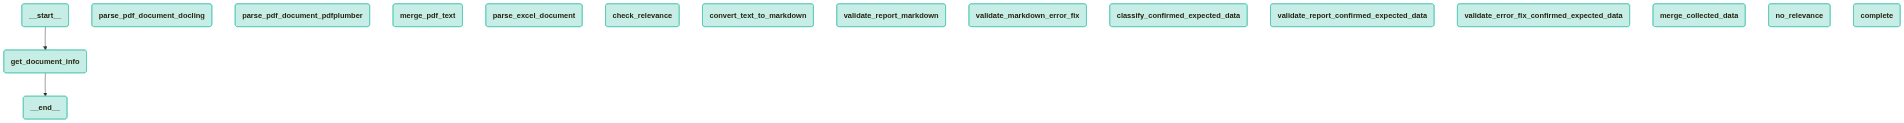

In [61]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(graph, xray=True)

# Graph 실행

In [62]:
# graph 실행

# text 추출 태스트

_document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/라이나_250826.xlsx"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(2차)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(액티브)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(퇴직)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/카디프_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/하나생명(액티브)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/iM라이프_250826.xls"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/ABL_250826.xlsx"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/DB_250826.xlsx"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/KB라이프_250826.xls"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/KB라이프(액티브)_250826.xls"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_overseas_settlement/LS.pdf"

_password = None
# _password = '345678'
result = graph.invoke({"file_path": _document_file_path, "password": _password})

markdown_text = result["markdown_text"]
confirmed_expected_data = result["confirmed_expected_data"]


   file_path : /Users/bhkim/20_code_test/documents/sample_variable_annuity/라이나_250826.xlsx
   file_name : 라이나_250826.xlsx
   file_ext : .xlsx
****************routing_parser****************
   .xlsx
excel_path: /Users/bhkim/20_code_test/documents/sample_variable_annuity/라이나_250826.xlsx
using pandas
****************routing_check_relevance****************
   relevance_score : yes
****************routing_check_relevance yes****************
   routing to  convert_text_to_markdown
****************START node_convert_text_to_markdown****************
########## text to markdown prompt ##########

  아래는 수익자가 보내온 변액일임펀드 설정/해지 지시서 파일에서 추출한 data입니다.

  아래의 추출 data를 LLM 모델이 잘 이해할 수 있도록 정리 지침에 따라 정리하세요.

  정리 지침에 따라 정리한 내용을 출력 형식에 따라 작성하세요.



  ### 변액일임펀드 설정/해지 지시서 파일 내용 ###

  [=== 시트: 당일 ===
 |  |  |  |  |  |  |  |  |  |  |  |  | 
■ Closing Date  :  | 2025-08-25 00:00:00 |  |  |  |  |  |  |  |  |  |  |  | 
■ 결제일          :  | 2025-08-26 00:00:00 |  |  |  |  |  |  |  |  |  |  |  | 발신자 : 라이나생명보험주식회사

GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT

# markdown 정리 결과

In [ ]:
print(f"file_name : {result['file_name']}")
# print(result_markdown_text)
display(Markdown(markdown_text))

# 확정분/청구분 분류 결과

In [ ]:
display(Markdown(confirmed_expected_data))